In [1]:
import os

base_path = '/mnt/c/Users/harsh/OneDrive/Documents/course/thesis/analysis'

os.chdir(base_path)

print(os.getcwd())

/mnt/c/Users/harsh/OneDrive/Documents/course/thesis/analysis


In [2]:
# Importing necessary datasets
import pandas as pd
import numpy as np

records = []

all_sheets = pd.read_excel('Final_test_results_full.xlsx', sheet_name=None)

all_data = pd.concat(all_sheets.values(), ignore_index=True)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(all_data)

time_sheets = pd.read_excel('time_final.xlsx', sheet_name=None)
for name, df in time_sheets.items():
    row = df.loc[df['Work'] == "Total Time (hrs)", ["Work", "Time (mins)"]]

    if not row.empty:
        row = row.assign(test=name)
        records.append(row)

time_full_tot = (
    pd.concat(
        [df.assign(test=name)           
         for name, df in time_sheets.items()],
        ignore_index=True
    )
    .loc[:, ["test", "Work", "Time (mins)"]]   
)


time_full_tot["Time (mins)"] = time_full_tot["Time (mins)"].round(2)

print(time_full_tot.head())

total_time = (
    pd.concat(records, ignore_index=True).loc[:, ["test", "Time (mins)"]]
)
total_time.columns = ["test", "Total Time (hrs)"]
print(total_time)

                             metric  test_result  article_result  \
0                     play_comp (n)    13.000000         13.0000   
1                     play_comp (%)     0.812500          0.8125   
2                 upper_CI_play (%)     1.000000          1.0000   
3                 lower_CI_play (%)     0.625000          0.6875   
4                     nicer_comp(n)     5.000000          5.0000   
5                    nicer_comp (%)     0.312500          0.3125   
6                 lower_CI_play (%)     0.125000          0.0625   
7                upper_CI_nicer (%)     0.562500          0.5000   
8                control_incomp (n)     5.000000          5.0000   
9                control_incomp (%)     0.312500          0.3125   
10                 nicer_incomp (n)    11.000000         11.0000   
11                 nicer_incomp (%)     0.687500          0.6875   
12                          p-value     0.011340          0.0500   
13                     upper_CI (%)     0.710035

In [3]:
records

[               Work  Time (mins)    test
 7  Total Time (hrs)     0.834167  case_1,
                Work  Time (mins)    test
 7  Total Time (hrs)     1.361167  case_2,
                Work  Time (mins)    test
 7  Total Time (hrs)     1.143333  case_3,
                Work  Time (mins)    test
 7  Total Time (hrs)     0.751833  case_4,
                Work  Time (mins)    test
 7  Total Time (hrs)     0.853167  case_5,
                Work  Time (mins)    test
 7  Total Time (hrs)       0.6255  case_6,
                Work  Time (mins)    test
 7  Total Time (hrs)        1.001  case_7,
                Work  Time (mins)    test
 7  Total Time (hrs)     0.722167  case_8,
                Work  Time (mins)    test
 7  Total Time (hrs)     0.771167  case_9,
                Work  Time (mins)     test
 7  Total Time (hrs)     0.568833  case_10,
                Work  Time (mins)     test
 7  Total Time (hrs)     0.758667  case_11,
                Work  Time (mins)     test
 7  Total Time (hr

In [4]:
# Checking counts of each sheet to ensure data integrity

counts = {name: df.shape[0] for name, df in all_sheets.items()}

print("Counts of each sheet:")
for sheet, nrows in counts.items():
    print(f" {sheet}: {nrows}")

# Checking count of all data combined
print("\nSum of individual sheet counts:", sum(counts.values()))
print("Rows in combined data:", all_data.shape[0])

Counts of each sheet:
 case_1: 18
 case_2: 9
 case_3: 13
 case_4: 10
 case_5: 10
 case_6: 9
 case_7: 13
 case_8: 18
 case_9: 13
 case_10: 45
 case_11: 20
 case_12: 66
 case_13: 35
 case_14: 35
 case_15: 30
 case_16: 15

Sum of individual sheet counts: 359
Rows in combined data: 359


In [5]:
# counts percentage for total errors by all results in each test for error_type_t_a

error_counts_t_a = (
    pd.Series({
        name: (df["error_type_t_a"] != "no_error").sum() 
        for name, df in all_sheets.items()
    },
    name = "error_counts_t_a_dict")
    .rename_axis("test")
    .reset_index(name="error_count")
)

error_percent_t_a = (
    pd.Series({
        name: ((df["error_type_t_a"] != "no_error").sum() / df.shape[0] * 100).round(2)
        for name, df in all_sheets.items()
    },
    name = "error_percent_t_a_dict")
    .rename_axis("test")
    .reset_index(name="error_percent(%)")
)

errors_t_a_time = pd.concat([total_time.set_index("test"), error_counts_t_a.set_index("test"), error_percent_t_a.set_index("test")], axis=1)

print(f"{errors_t_a_time}")

         Total Time (hrs)  error_count  error_percent(%)
test                                                    
case_1           0.834167            9             50.00
case_2           1.361167            9            100.00
case_3           1.143333           12             92.31
case_4           0.751833            6             60.00
case_5           0.853167            2             20.00
case_6           0.625500            2             22.22
case_7           1.001000            3             23.08
case_8           0.722167           12             66.67
case_9           0.771167            9             69.23
case_10          0.568833            3              6.67
case_11          0.758667            4             20.00
case_12          1.051500            1              1.52
case_13          0.792667            2              5.71
case_14          0.744000            2              5.71
case_15          1.185167            3             10.00
case_16          0.926500      

In [ ]:
# Calculating average time required across cases in minutes. Weighted average also calculated basis number of errors in each case

weight_avg_time = np.average(errors_t_a_time["Total Time (hrs)"], weights=errors_t_a_time["error_count"])*60
avg_time = errors_t_a_time["Total Time (hrs)"].mean() * 60
min_time = errors_t_a_time["Total Time (hrs)"].min() * 60
max_time = errors_t_a_time["Total Time (hrs)"].max() * 60
print(f"Weighted average time: {weight_avg_time.round(2)} minutes")
print(f"Average time: {avg_time.round(2)} minutes")
print(f"Minimum time: {min_time.round(2)} minutes")
print(f"Maximum time: 1 hr {(((max_time/60)-1)*60).round(2)} minutes")


Weighted average time: 54.72 minutes
Average time: 52.84 minutes
Minimum time: 34.13 minutes
Maximum time: 1 hr 21.67 minutes


In [7]:
error_type_cols = all_data.filter(like="error_type").columns

unique_vals = {col: all_data[col].unique().tolist() for col in error_type_cols}

for col, vals in unique_vals.items():
    print(f"{col}: {vals}")

error_type_t_a: ['no_error', 'minor_error', 'major_error', 'decision_error']
error_type_t_h: ['no_error', 'minor_error', 'major_error', 'decision_error']
error_type_a_h: ['no_error', 'minor_error', 'major_error']


In [9]:
metrics_col = all_data['metric'].unique()
print("\nMetrics column unique values:", metrics_col)


Metrics column unique values: ['play_comp (n)' 'play_comp (%)' 'upper_CI_play (%)' 'lower_CI_play (%)'
 'nicer_comp(n)' 'nicer_comp (%)' 'upper_CI_nicer (%)'
 'control_incomp (n)' 'control_incomp (%)' 'nicer_incomp (n)'
 'nicer_incomp (%)' 'p-value' 'upper_CI (%)' 'lower_CI (%)'
 'Prime accuracy' 'upper_CI' 'lower_CI' 'df' 't-statistic'
 'Target Accuracy' 'mean RT repeat' 'mean RT repeat (%)' 'mean RT swtich'
 'mean RT swtich (%)' 'mean RT predictive' 'mean RT nonpredictive'
 'mean RT difference' 'p-value accuracy / error rate' 'F-statistic'
 'df (F-test)' 'eta-squared' 'df1 (F-test)' 'df2 (F-test)'
 'total prticipant' 'particpiant exchange info' '%age' 'chi-square'
 'implicit racial bias mean' 'implicit racial bias sd'
 'explicit racial bias mean' 'explicit racial bias sd'
 'warmth african americans mean' 'warmth african americans sd'
 'warmth european americans mean' 'warmth european americans sd'
 'conception risk mean' 'conception risk sd' 'correlation r'
 'correlation CI upper (9

In [ ]:
# Creating classification for test results

entral_tendency = [
    "Prime accuracy", "Target Accuracy",
    "mean RT repeat", "mean RT repeat (%)",
    "mean RT swtich", "mean RT swtich (%)",
    "mean RT predictive", "mean RT nonpredictive",
    "implicit racial bias mean", "explicit racial bias mean",
    "warmth african americans mean", "warmth european americans mean",
    "conception risk mean", "Pitch",
    "intensity_pain_mean", "intensity_no-pain_mean",
    "unpleasentness_pain_mean", "unpleasentness_no-pain_mean",
    "positive_effect_pain_mean", "positive_effect_no-pain_mean",
    "negative_effect_pain_mean", "negative_effect_no-pain_mean",
    "threatening_pain_mean", "threatening_no-pain_mean",
    "challenging_pain_mean", "challenging_no-pain_mean",
    "bonding_pain_mean", "bonding_no-pain_mean",
    "Time 1 mean", "Time 2 mean",
]

variation_uncertainty = [
    "upper_CI_play (%)", "lower_CI_play (%)", "upper_CI_nicer (%)",
    "upper_CI (%)", "lower_CI (%)", "upper CI", "lower CI",
    "implicit racial bias sd", "explicit racial bias sd",
    "warmth african americans sd", "warmth european americans sd",
    "conception risk sd", "correlation CI upper (95%)",
    "correlation CI lower (95%)", "Pitch variability",
    "Loudness variability", "intensity_pain_sd", "intensity_no-pain_sd",
    "unpleasentness_pain_sd", "positive_effect_pain_sd",
    "negative_effect_pain_sd", "threatening_pain_sd",
    "challenging_pain_sd", "bonding_pain_sd",
    "Time 1 sd", "Time 2 sd", "CI lower", "CI upper",
    "lower CI", "upper CI", "upper_CI", "lower_CI", "positive_effect_no-pain_sd",
    "negative_effect_no-pain_sd", "threatening_no-pain_sd",  "challenging_no-pain_sd",
     "bonding_no-pain_sd"
]

p_values = [
    "p-value", "p-value accuracy / error rate",
]

effect_sizes = [
    "mean RT difference", "eta-squared", "partial eta-squared",
    "partial eta-sq.", "correlation r", "cohen's d", "cohens d",
    "Time 2 - Time 1",
]

test_statistics = [
    "t-statistic", "t-stat", "F-statistic", "F-stat", "chi-square",
]

counts_props = [
    "play_comp (n)", "play_comp (%)", "nicer_comp(n)", "nicer_comp (%)",
    "control_incomp (n)", "control_incomp (%)",
    "nicer_incomp (n)", "nicer_incomp (%)", "total prticipant",
    "particpiant exchange info", "%age",
    "reward p<0.1 block-1 control", "reward p<0.1 block-4 control",
    "reward p<0.1 block-1 yoked", "reward p<0.1 block-4 yoked",
    "reward p=0.2 block-1 control", "reward p=0.2 block-4 control",
    "reward p=0.2 block-1 yoked", "reward p=0.2 block-4 yoked",
    "Behind", "Tied", "Ahead", "Not behind", "behind", "tied", "ahead",
]

degrees_freedom = [
    "df", "df (F-test)", "df1 (F-test)", "df2 (F-test)", "df1", "df2",
]


metric_category_map = {m: "central tendency measures" for m in central_tendency}
metric_category_map.update({m: "variation/ uncertainty measures" for m in variation_uncertainty})
metric_category_map.update({m: "p-values" for m in p_values})
metric_category_map.update({m: "effect sizes" for m in effect_sizes})
metric_category_map.update({m: "test statistics" for m in test_statistics})
metric_category_map.update({m: "counts/ proportions" for m in counts_props})
metric_category_map.update({m: "degrees of freedom" for m in degrees_freedom})


all_data["metric_category"] = (
    all_data["metric"]
    .map(metric_category_map)                  
)


all_data[["metric", "metric_category"]].head()


,metric,metric_category
0,play_comp (n),counts/ proportions
1,play_comp (%),counts/ proportions
2,upper_CI_play (%),variation/ uncertainty measures
3,lower_CI_play (%),variation/ uncertainty measures
4,nicer_comp(n),counts/ proportions


In [11]:
# calculate error type counts and percentages for test vs hardwicke
counts = all_data['error_type_t_h'].value_counts()

percentages = counts / len(all_data) * 100

error_t_h_summary = (
    pd.DataFrame({'count': counts, 'percent': percentages.round(2)})
    .rename_axis('error_type')
    .reset_index()
)

print(error_t_h_summary)

       error_type  count  percent
0        no_error    290    80.78
1     major_error     38    10.58
2     minor_error     30     8.36
3  decision_error      1     0.28


In [12]:
# error count / percent for each test for error_type_t_h

err_cols = ["no_error", "minor_error", "major_error", "decision_error"]

rows = []
for name, df in all_sheets.items():
    vc = df["error_type_t_h"].value_counts().reindex(err_cols, fill_value=0)
    vc.name = name                     
    rows.append(vc)

error_counts_by_test = pd.concat(rows, axis=1).T      

error_counts_by_test = error_counts_by_test.astype(int)

print(error_counts_by_test)

error_type_t_h  no_error  minor_error  major_error  decision_error
case_1                10            1            7               0
case_2                 0            1            8               0
case_3                 1            9            3               0
case_4                 7            2            1               0
case_5                10            0            0               0
case_6                 7            0            2               0
case_7                10            0            3               0
case_8                 6            6            5               1
case_9                12            0            1               0
case_10               44            1            0               0
case_11               20            0            0               0
case_12               61            5            0               0
case_13               33            1            1               0
case_14               35            0            0            

In [13]:
# error count / percent for each test for error_type_a_h
rows_a_h = []
for name, df in all_sheets.items():
    vc = df["error_type_a_h"].value_counts().reindex(err_cols, fill_value=0)
    vc.name = name                     
    rows_a_h.append(vc)

error_counts_by_test_a_h = pd.concat(rows_a_h, axis=1).T

error_counts_by_test_a_h = error_counts_by_test_a_h.astype(int)

print(error_counts_by_test_a_h)

error_type_a_h  no_error  minor_error  major_error  decision_error
case_1                14            4            0               0
case_2                 2            7            0               0
case_3                 3            5            5               0
case_4                 5            3            2               0
case_5                 9            1            0               0
case_6                 9            0            0               0
case_7                10            0            3               0
case_8                16            1            1               0
case_9                 4            8            1               0
case_10               41            3            1               0
case_11               16            4            0               0
case_12               60            6            0               0
case_13               32            1            2               0
case_14               33            2            0            

In [14]:
# error count / percent for each test for error_type_t_a
rows_t_a = []
for name, df in all_sheets.items():
    vc = df["error_type_t_a"].value_counts().reindex(err_cols, fill_value=0)
    vc.name = name                     
    rows_t_a.append(vc)

error_counts_by_test_t_a = pd.concat(rows_t_a, axis=1).T

error_counts_by_test_t_a = error_counts_by_test_t_a.astype(int)

print(error_counts_by_test_t_a)

error_type_t_a  no_error  minor_error  major_error  decision_error
case_1                 9            2            7               0
case_2                 0            1            8               0
case_3                 1            4            8               0
case_4                 4            3            3               0
case_5                 8            1            1               0
case_6                 7            0            2               0
case_7                10            0            3               0
case_8                 6            6            5               1
case_9                 4            8            1               0
case_10               42            2            1               0
case_11               16            4            0               0
case_12               65            1            0               0
case_13               33            0            2               0
case_14               33            2            0            

In [15]:
# create split per metric category
error_counts = (
    pd.crosstab(
        all_data["metric_category"],
        all_data["error_type_t_h"]
    )
.reindex(
    [
        "central tendency measures",
            "variation/ uncertainty measures",
            "p-values",
            "effect sizes",
            "test statistics",
            "counts/ proportions",
            "degrees of freedom"
    ]
).fillna(0)
.astype(int)
)
print("\nError counts per metric category:\n", error_counts)


Error counts per metric category:
 error_type_t_h                   decision_error  major_error  minor_error  \
metric_category                                                             
central tendency measures                     0            4            6   
variation/ uncertainty measures               0           14           15   
p-values                                      1            7            1   
effect sizes                                  0            6            1   
test statistics                               0            5            5   
counts/ proportions                           0            1            1   
degrees of freedom                            0            1            1   

error_type_t_h                   no_error  
metric_category                            
central tendency measures              34  
variation/ uncertainty measures        47  
p-values                               45  
effect sizes                           37  
test s

In [16]:
row_percent = (
    error_counts.div(error_counts.sum(axis=0), axis=1).mul(100).round(2)
)
print(row_percent)

error_type_t_h                   decision_error  major_error  minor_error  \
metric_category                                                             
central tendency measures                   0.0        10.53        20.00   
variation/ uncertainty measures             0.0        36.84        50.00   
p-values                                  100.0        18.42         3.33   
effect sizes                                0.0        15.79         3.33   
test statistics                             0.0        13.16        16.67   
counts/ proportions                         0.0         2.63         3.33   
degrees of freedom                          0.0         2.63         3.33   

error_type_t_h                   no_error  
metric_category                            
central tendency measures           11.72  
variation/ uncertainty measures     16.21  
p-values                            15.52  
effect sizes                        12.76  
test statistics                     12.76 

In [17]:
# Count of each type of error per study according to t_a vs a_h
counts_t_a = all_data['error_type_t_a'].value_counts()

percentages_t_a = counts_t_a / len(all_data) * 100

error_t_a_summary = (
    pd.DataFrame({'count': counts_t_a, 'percent': percentages_t_a.round(2)})
    .rename_axis('error_type')
    .reset_index()
)

print(error_t_a_summary, '\n')

counts_a_h = all_data['error_type_a_h'].value_counts()

percentages_a_h = counts_a_h / len(all_data) * 100

error_a_h_summary = (
    pd.DataFrame({'count': counts_a_h, 'percent': percentages_a_h.round(2)})
    .rename_axis('error_type')
    .reset_index()
)

print(error_a_h_summary, '\n')

print(error_t_h_summary)


       error_type  count  percent
0        no_error    275    76.60
1     major_error     43    11.98
2     minor_error     40    11.14
3  decision_error      1     0.28 

    error_type  count  percent
0     no_error    290    80.78
1  minor_error     49    13.65
2  major_error     20     5.57 

       error_type  count  percent
0        no_error    290    80.78
1     major_error     38    10.58
2     minor_error     30     8.36
3  decision_error      1     0.28


In [ ]:
# Frequency distribution table between different comparisons t_h x a_h and t_h x t_a

error_rows_t_h = all_data.query('error_type_t_h != "no error"')

t_h_vs_a_h = pd.crosstab(
    error_rows_t_h['error_type_a_h'],
    error_rows_t_h['error_type_t_h'],  
    margins=True, 
    margins_name='Total'
).astype(int)

t_h_vs_t_a = pd.crosstab(
    error_rows_t_h['error_type_t_a'],
    error_rows_t_h['error_type_t_h'],  
    margins=True, 
    margins_name='Total'
).astype(int)

print("error_type_t_h x error_type_a_h:")
print(t_h_vs_a_h)
print("\nerror_type_t_h x error_type_t_a:")
print(t_h_vs_t_a)


error_type_t_h x error_type_a_h:
error_type_t_h  decision_error  major_error  minor_error  no_error  Total
error_type_a_h                                                           
major_error                  0           12            4         4     20
minor_error                  0           10           17        22     49
no_error                     1           16            9       264    290
Total                        1           38           30       290    359

error_type_t_h x error_type_t_a:
error_type_t_h  decision_error  major_error  minor_error  no_error  Total
error_type_t_a                                                           
decision_error               1            0            0         0      1
major_error                  0           32            5         6     43
minor_error                  0            1           17        22     40
no_error                     0            5            8       262    275
Total                        1           38  

In [19]:
# Break down of error types in t_h vs a_h - similar


records_t_h_vs_a_h_mismatch = []

for name, df in all_sheets.items():
    mismatch_rows = df[
        (df["error_type_t_h"] == df["error_type_a_h"])
    ]
    if not mismatch_rows.empty:
        records_t_h_vs_a_h_mismatch.append(
            mismatch_rows.assign(sheet=name)[
                ["sheet", "error_type_t_h", "error_type_a_h"]
            ]
        )

mismatch_long = pd.concat(records_t_h_vs_a_h_mismatch, ignore_index=True)


match_summary = (
    mismatch_long
      .groupby(["sheet", "error_type_t_h", "error_type_a_h"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values(["sheet", "count"], ascending=[True, False])
)

print(match_summary)


# Break down of error types in t_h vs a_h - not similar


records_t_h_vs_a_h_match = []

for name, df in all_sheets.items():
    mismatch_rows = df[
        (df["error_type_t_h"] != df["error_type_a_h"])
    ]
    if not mismatch_rows.empty:
        records_t_h_vs_a_h_match.append(
            mismatch_rows.assign(sheet=name)[
                ["sheet", "error_type_t_h", "error_type_a_h"]
            ]
        )

mismatch_long = pd.concat(records_t_h_vs_a_h_match, ignore_index=True)


mismatch_summary = (
    mismatch_long
      .groupby(["sheet", "error_type_t_h", "error_type_a_h"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values(["sheet", "count"], ascending=[True, False])
)

print("\n\n", mismatch_summary)  


      sheet error_type_t_h error_type_a_h  count
0    case_1       no_error       no_error      9
2   case_10       no_error       no_error     41
1   case_10    minor_error    minor_error      1
3   case_11       no_error       no_error     16
5   case_12       no_error       no_error     60
4   case_12    minor_error    minor_error      5
8   case_13       no_error       no_error     32
6   case_13    major_error    major_error      1
7   case_13    minor_error    minor_error      1
9   case_14       no_error       no_error     33
11  case_15       no_error       no_error     26
10  case_15    minor_error    minor_error      1
14  case_16       no_error       no_error      6
12  case_16    major_error    major_error      5
13  case_16    minor_error    minor_error      1
16   case_3    minor_error    minor_error      5
15   case_3    major_error    major_error      1
17   case_3       no_error       no_error      1
19   case_4       no_error       no_error      4
18   case_4    minor

In [20]:
# Break down of error types in t_a vs a_h - not similar


records_t_a_vs_a_h_mismatch = []

for name, df in all_sheets.items():
    mismatch_rows = df[
        (df["error_type_t_a"] != df["error_type_a_h"])
    ]
    if not mismatch_rows.empty:
        records_t_a_vs_a_h_mismatch.append(
            mismatch_rows.assign(sheet=name)[
                ["sheet", "error_type_t_a", "error_type_a_h"]
            ]
        )

mismatch_long = pd.concat(records_t_a_vs_a_h_mismatch, ignore_index=True)


mismatch_summary = (
    mismatch_long
      .groupby(["sheet", "error_type_t_a", "error_type_a_h"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values(["sheet", "count"], ascending=[True, False])
)

print("mismatch summary \n", mismatch_summary)  

# Break down of error types in t_a vs a_h - similar


records_t_a_vs_a_h_match = []

for name, df in all_sheets.items():
    match_rows = df[
        (df["error_type_t_a"] == df["error_type_a_h"])
    ]
    if not match_rows.empty:
        records_t_a_vs_a_h_match.append(
            match_rows.assign(sheet=name)[
                ["sheet", "error_type_t_a", "error_type_a_h"]
            ]
        )

match_long = pd.concat(records_t_a_vs_a_h_match, ignore_index=True)


match_summary = (
    match_long
      .groupby(["sheet", "error_type_t_a", "error_type_a_h"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values(["sheet", "count"], ascending=[True, False])
)

print("\n\n", "match summary \n", match_summary)  



mismatch summary 
       sheet  error_type_t_a error_type_a_h  count
1    case_1     major_error       no_error      4
0    case_1     major_error    minor_error      3
2    case_1     minor_error       no_error      1
3   case_10        no_error    minor_error      1
4   case_12        no_error    minor_error      5
5   case_13     major_error       no_error      1
6   case_13        no_error    major_error      1
7   case_13        no_error    minor_error      1
8   case_15     major_error       no_error      1
9   case_15        no_error    minor_error      1
13  case_16        no_error    major_error      4
12  case_16     minor_error       no_error      2
10  case_16     major_error       no_error      1
11  case_16     minor_error    major_error      1
14   case_2     major_error    minor_error      7
15   case_2     major_error       no_error      1
16   case_2     minor_error       no_error      1
18   case_3     major_error       no_error      2
17   case_3     major_error    

In [21]:
# Break down of error types in t_a vs t_h - not similar


records_t_a_vs_t_h_mismatch = []

for name, df in all_sheets.items():
    mismatch_rows = df[
        (df["error_type_t_a"] != df["error_type_t_h"])
    ]
    if not mismatch_rows.empty:
        records_t_a_vs_t_h_mismatch.append(
            mismatch_rows.assign(sheet=name)[
                ["sheet", "error_type_t_a", "error_type_t_h"]
            ]
        )

mismatch_long = pd.concat(records_t_a_vs_t_h_mismatch, ignore_index=True)


mismatch_summary = (
    mismatch_long
      .groupby(["sheet", "error_type_t_a", "error_type_t_h"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values(["sheet", "count"], ascending=[True, False])
)

print("mismatch summary \n", mismatch_summary)  

# Break down of error types in t_a vs t_h - similar


records_t_a_vs_t_h_match = []

for name, df in all_sheets.items():
    match_rows = df[
        (df["error_type_t_a"] == df["error_type_t_h"])
    ]
    if not match_rows.empty:
        records_t_a_vs_t_h_match.append(
            match_rows.assign(sheet=name)[
                ["sheet", "error_type_t_a", "error_type_t_h"]
            ]
        )

match_long = pd.concat(records_t_a_vs_t_h_match, ignore_index=True)


match_summary = (
    match_long
      .groupby(["sheet", "error_type_t_a", "error_type_t_h"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values(["sheet", "count"], ascending=[True, False])
)

print("\n\n match summary \n", match_summary) 

mismatch summary 
       sheet error_type_t_a error_type_t_h  count
0    case_1    minor_error       no_error      1
2   case_10    minor_error       no_error      2
1   case_10    major_error       no_error      1
3   case_10       no_error    minor_error      1
4   case_11    minor_error       no_error      4
6   case_12       no_error    minor_error      5
5   case_12    minor_error       no_error      1
7   case_13    major_error       no_error      2
8   case_13       no_error    major_error      1
9   case_13       no_error    minor_error      1
10  case_14    minor_error       no_error      2
11  case_15    minor_error       no_error      2
12  case_15       no_error    minor_error      1
14  case_16       no_error    major_error      4
13  case_16    minor_error    major_error      1
15   case_3    major_error    minor_error      5
16   case_4    major_error       no_error      2
17   case_4    minor_error       no_error      1
18   case_5    major_error       no_error      1
1

In [ ]:
# columns needed

err_cols = ["error_type_t_a", "error_type_a_h", "error_type_t_h"]

records = []

for name, df in all_sheets.items():
    # keep only rows where at least one of the three differs
    mismatch_rows = df.loc[df[err_cols].nunique(axis=1) > 0, err_cols]

    if not mismatch_rows.empty:
        records.append(mismatch_rows.assign(sheet=name))

triplet_long = pd.concat(records, ignore_index=True)


# count every unique triplet (t_h, t_a, a_h) per sheet
triplet_summary = (
    triplet_long
      .groupby(["sheet", "error_type_t_a", "error_type_a_h", "error_type_t_h"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values(["sheet", "count"], ascending=[False, True])
)

print(triplet_summary)

overall = (
    triplet_long
      .groupby(["error_type_t_h", "error_type_t_a", "error_type_a_h"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values("count", ascending=True)
)

print(overall)


     sheet  error_type_t_a error_type_a_h  error_type_t_h  count
58  case_9     major_error    major_error     major_error      1
60  case_9        no_error       no_error        no_error      4
59  case_9     minor_error    minor_error        no_error      8
52  case_8  decision_error       no_error  decision_error      1
53  case_8     major_error    major_error     major_error      1
..     ...             ...            ...             ...    ...
2   case_1     minor_error    minor_error        no_error      1
3   case_1     minor_error       no_error     minor_error      1
0   case_1     major_error    minor_error     major_error      3
1   case_1     major_error       no_error     major_error      4
4   case_1        no_error       no_error        no_error      9

[61 rows x 5 columns]
    error_type_t_h  error_type_t_a error_type_a_h  count
0   decision_error  decision_error       no_error      1
4      major_error     minor_error    major_error      1
7      minor_error     maj

In [23]:
from statsmodels.stats.proportion import proportion_confint

# 95 % confidence interval (Wilson method)

def ci_calc(k, n, type_err, alpha=0.05):
    ci_low, ci_high = proportion_confint(k, n, alpha=alpha, method="wilson")
    pct = k / n * 100
    print (f"% {type_err} = {pct:.2f}%  (95% CI {ci_low*100:.2f}% – {ci_high*100:.2f}%)")


In [24]:
error_terms = ['no_error', 'minor_error', 'major_error', 'decision_error']

print("errors CI by t_h:")
for i in error_terms:
    k = (all_data['error_type_t_h'] == i).sum()
    n = len(all_data)
    ci_calc(k, n, i, alpha=0.05)

print("\nerrors CI by a_h:")
for i in error_terms[:-1]:
    k = (all_data['error_type_a_h'] == i).sum()
    n = len(all_data)
    ci_calc(k, n, i, alpha=0.05)

print("\nerrors CI by t_a:")
for i in error_terms:
    k = (all_data['error_type_t_a'] == i).sum()
    n = len(all_data)
    ci_calc(k, n, i, alpha=0.05)

errors CI by t_h:
% no_error = 80.78%  (95% CI 76.39% – 84.52%)
% minor_error = 8.36%  (95% CI 5.92% – 11.68%)
% major_error = 10.58%  (95% CI 7.81% – 14.20%)
% decision_error = 0.28%  (95% CI 0.05% – 1.56%)

errors CI by a_h:
% no_error = 80.78%  (95% CI 76.39% – 84.52%)
% minor_error = 13.65%  (95% CI 10.48% – 17.59%)
% major_error = 5.57%  (95% CI 3.63% – 8.45%)

errors CI by t_a:
% no_error = 76.60%  (95% CI 71.95% – 80.69%)
% minor_error = 11.14%  (95% CI 8.29% – 14.82%)
% major_error = 11.98%  (95% CI 9.02% – 15.75%)
% decision_error = 0.28%  (95% CI 0.05% – 1.56%)


In [ ]:
# reusable mask for rows to keep
def error_mask(df):
    return ~df["error_type_t_a"].isin(["no_error", "minor_error"])

# counts
error_counts_t_a_corr = (
    pd.Series(
        {
            name: error_mask(df).sum()          
            for name, df in all_sheets.items()
        },
        name="error_counts_t_a_dict",
    )
    .rename_axis("test")
    .reset_index(name="error_count")
)

# percentages  (numerator uses the same mask; denominator stays total rows)
error_percent_t_a_corr = (
    pd.Series(
        {
            name: (error_mask(df).sum() / df.shape[0] * 100).round(2)
            for name, df in all_sheets.items()
        },
        name="error_percent_t_a_dict",
    )
    .rename_axis("test")
    .reset_index(name="error_percent(%)")
)


# final table
errors_t_a_time_corr = (
    pd.concat(
        [
            total_time.set_index("test"),
            error_counts_t_a_corr.set_index("test"),
            error_percent_t_a_corr.set_index("test"),
        ],
        axis=1,
    )
)

print(errors_t_a_time_corr)



         Total Time (hrs)  error_count  error_percent(%)
test                                                    
case_1           0.834167            7             38.89
case_2           1.361167            8             88.89
case_3           1.143333            8             61.54
case_4           0.751833            3             30.00
case_5           0.853167            1             10.00
case_6           0.625500            2             22.22
case_7           1.001000            3             23.08
case_8           0.722167            6             33.33
case_9           0.771167            1              7.69
case_10          0.568833            1              2.22
case_11          0.758667            0              0.00
case_12          1.051500            0              0.00
case_13          0.792667            2              5.71
case_14          0.744000            0              0.00
case_15          1.185167            1              3.33
case_16          0.926500      

In [26]:
# Correlation between time and error count / percentage - spearman correlation as we assume non-normal distribution

from scipy.stats import spearmanr
rho, p_val = spearmanr(
    errors_t_a_time_corr["error_count"],
    errors_t_a_time_corr["Total Time (hrs)"]
)
print(f"rho = {rho:.3f},   p-value = {p_val:.4f}")

rho = 0.224,   p-value = 0.4051


# Plots

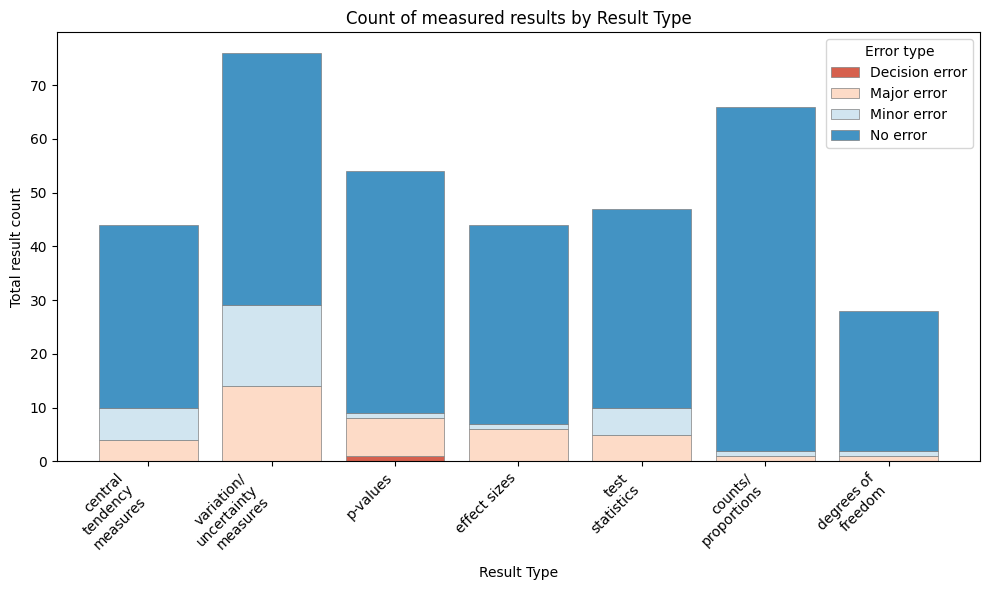

In [ ]:
# Errors encountered by type of result

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import textwrap


error_types = error_counts.columns                     
x = range(len(error_counts))                           

fig, ax = plt.subplots(figsize=(10, 6))

bottom = [0] * len(error_counts)


colors = sns.color_palette("RdBu", n_colors=len(error_types))

label_map = {
    "no_error":        "No error",
    "minor_error":     "Minor error",
    "major_error":     "Major error",
    "decision_error":  "Decision error",
}

for err, col in zip(error_types, itertools.cycle(colors)):
    ax.bar(
        x,
        error_counts[err],
        bottom=bottom,
        color=col,
        edgecolor="gray",
        linewidth=0.5,
        label=label_map.get(err, err)
    )
    bottom = [b + v for b, v in zip(bottom, error_counts[err])]

wrap_width = 12
wrapped_labels = [
    textwrap.fill(label, width=wrap_width, break_long_words=False)
    for label in error_counts.index
]

ax.set_xticks(list(x))
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

ax.set_xlabel("Result Type")
ax.set_ylabel("Total result count")
ax.set_title("Count of measured Test Results by Type of Results")
ax.legend(title="Error type")
plt.tight_layout()
plt.show()


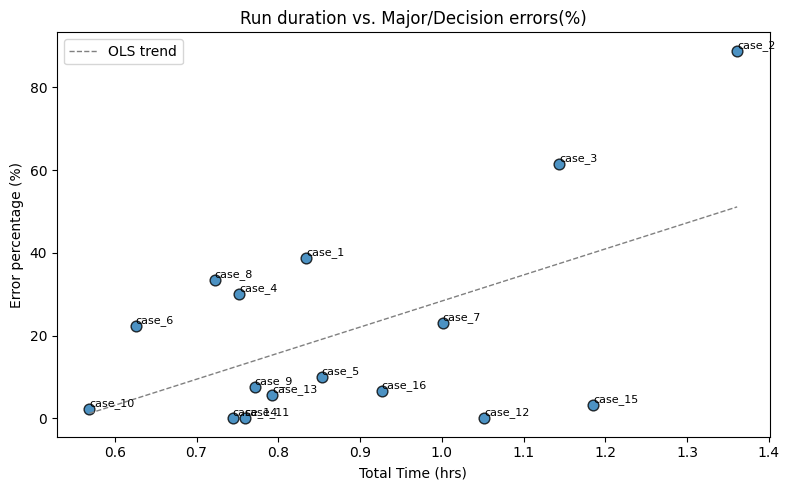

In [28]:
df_plot = errors_t_a_time_corr.reset_index()         

fig, ax = plt.subplots(figsize=(8, 5))


ax.scatter(
    df_plot["Total Time (hrs)"],
    df_plot["error_percent(%)"],
    s=60,               
    edgecolor="black",  
    alpha=0.8
)


for _, row in df_plot.iterrows():
    ax.text(
        row["Total Time (hrs)"],
        row["error_percent(%)"],
        row["test"],
        fontsize=8,
        ha="left",
        va="bottom"
    )


z = np.polyfit(df_plot["Total Time (hrs)"], df_plot["error_percent(%)"], 1)
p = np.poly1d(z)
x_vals = np.linspace(df_plot["Total Time (hrs)"].min(),
                     df_plot["Total Time (hrs)"].max(), 100)
ax.plot(x_vals, p(x_vals), ls="--", lw=1, color="gray", label="OLS trend")

ax.set_xlabel("Total Time (hrs)")
ax.set_ylabel("Error percentage (%)")
ax.set_title("Run duration vs. Major/Decision errors(%)")
ax.legend()
plt.tight_layout()
plt.show()


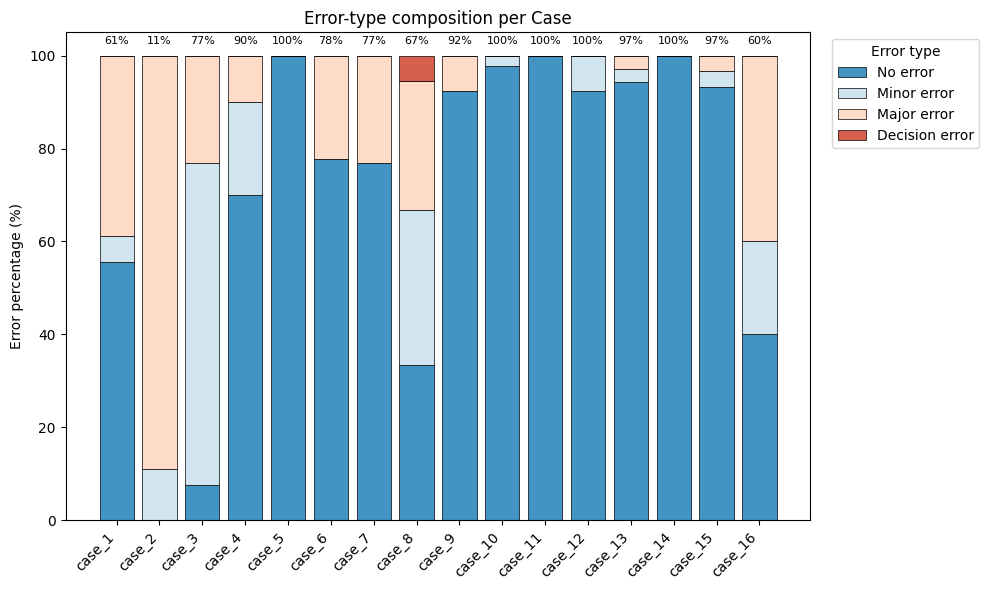

In [ ]:
import re


err_cols = ["no_error", "minor_error", "major_error", "decision_error"]

sorted_counts = error_counts_by_test.sort_values("major_error", ascending=False)

df_pct = (
    sorted_counts[err_cols]          
      .div(sorted_counts[err_cols].sum(axis=1), axis=0)
      .mul(100)
)

df_pct["none_error"] = df_pct[["no_error", "minor_error"]].sum(axis=1)

# order the rows numerically
df_pct_sorted = (
    df_pct.reset_index()
          .assign(num=lambda d: d["index"].str.extract(r"(\d+)").astype(int))
          .sort_values("num")
          .set_index("index")
          .drop(columns="num")
)

# colour palette + legend labelling
colors = sns.color_palette("RdBu_r", n_colors=len(err_cols))
color_map   = dict(zip(err_cols, colors))
label_map   = {
    "no_error":        "No error",
    "minor_error":     "Minor error",
    "major_error":     "Major error",
    "decision_error":  "Decision error",
}

fig, ax = plt.subplots(figsize=(10, 6))
bottom = pd.Series(0, index=df_pct_sorted.index, dtype=float)

for col in err_cols:
    ax.bar(
        df_pct_sorted.index, df_pct_sorted[col],
        bottom=bottom,
        color=color_map[col],
        edgecolor="black", linewidth=0.5,
        label=label_map[col]          
    )
    bottom += df_pct_sorted[col]

for x, pct in zip(df_pct_sorted.index, df_pct_sorted["none_error"]):
    ax.text(x, 102, f"{pct:.0f}%", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Error percentage (%)")
ax.set_ylim(0, 105)
ax.set_title("Error-type composition per Case")
ax.legend(title="Error type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


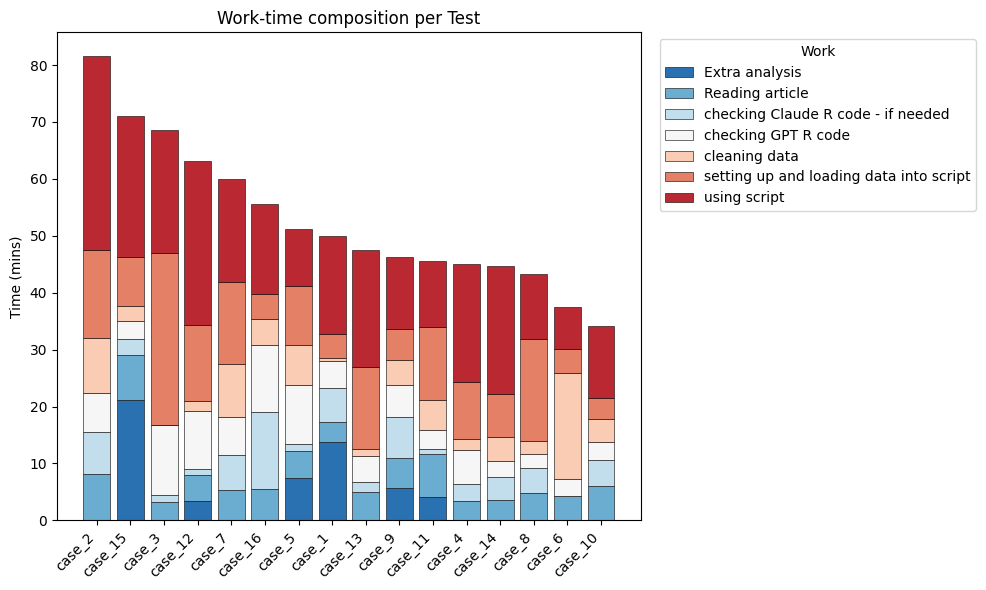

In [ ]:
pivot = (
    time_full_tot
      .pivot_table(index="test", columns="Work", values="Time (mins)", aggfunc="sum")
      .fillna(0)
)

# sort tests by descending total time
pivot_sorted = (
    pivot.assign(total=pivot.sum(axis=1))        
         .sort_values("total", ascending=False)  
         .drop(columns="total")                 
)

pivot_clean = pivot_sorted.drop(columns="Total Time (hrs)", errors="ignore")

work_cols = pivot_clean.columns.tolist()
colors = sns.color_palette("RdBu_r", n_colors=len(work_cols))
color_map = dict(zip(work_cols, colors))

bottom = pd.Series(0, index=pivot_clean.index, dtype=float)
fig, ax = plt.subplots(figsize=(10, 6))

for col in work_cols:
    ax.bar(
        pivot_clean.index,
        pivot_clean[col],
        bottom=bottom,
        color=color_map[col],
        edgecolor="black",
        linewidth=0.4,
        label=col,
    )
    bottom += pivot_sorted[col]

ax.set_ylabel("Time (mins)")
ax.set_title("Work‑time composition per Test")
ax.legend(title="Work", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
